In [ ]:
## Day 11 - Feature Engineering

What I learned today:
- Feature Engineering = creating new columns from existing ones
- Added FamilySize, IsAlone, Title to Titanic dataset
- Accuracy improved from 81.01% to 81.56%
- Title was most valuable new feature (15% importance)
- FamilySize beat SibSp + Parch separately
- IsAlone was nearly useless — duplicated FamilySize info
- Always check feature importance after adding new features

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Clean
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop("Cabin", axis=1)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

print("Data loaded and cleaned!")
print("Shape:", df.shape)

Data loaded and cleaned!
Shape: (891, 11)


In [3]:
# Original features only
X_baseline = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, predictions)
print(f"Baseline Accuracy (no feature engineering): {baseline_accuracy * 100:.2f}%")

Baseline Accuracy (no feature engineering): 81.01%


In [5]:
#Feature 1 : Family Size
#Alone on ship or with family
df["FamilySize"] = df["SibSp"]+df["Parch"]+1

#Feature 2 : Is Alone
#1= travelling alone, 0= travelling with family
df["IsAlone"] = (df["FamilySize"] ==1).astype(int)

# Feature 3: Title from Name
# Extract Mr, Mrs, Miss, Master from name
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')

# Simplify rare titles
df["Title"] = df["Title"].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df["Title"] = df["Title"].replace('Mlle', 'Miss')
df["Title"] = df["Title"].replace('Ms', 'Miss')
df["Title"] = df["Title"].replace('Mme', 'Mrs')

# Convert Title to numbers
df["Title"] = df["Title"].map(
    {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
df["Title"] = df["Title"].fillna(0)

print("New features created!")
print(df[["Name", "Title", "FamilySize", "IsAlone"]].head(10))

New features created!
                                                Name  Title  FamilySize  \
0                            Braund, Mr. Owen Harris      1           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      3           2   
2                             Heikkinen, Miss. Laina      2           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      3           2   
4                           Allen, Mr. William Henry      1           1   
5                                   Moran, Mr. James      1           1   
6                            McCarthy, Mr. Timothy J      1           1   
7                     Palsson, Master. Gosta Leonard      4           5   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)      3           3   
9                Nasser, Mrs. Nicholas (Adele Achem)      3           2   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  
5        1  
6        1  
7        0  
8        0  
9        0  


In [6]:
# Now use original features PLUS our new features
X_new = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", 
            "FamilySize", "IsAlone", "Title"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train, y_train)
predictions_new = model_new.predict(X_test)

new_accuracy = accuracy_score(y_test, predictions_new)

print(f"Baseline Accuracy:             81.01%")
print(f"Accuracy with new features:    {new_accuracy * 100:.2f}%")
print()
if new_accuracy > 0.8101:
    print("Feature Engineering IMPROVED the model! ✅")
else:
    print("No improvement this time. Let's analyse why.")

Baseline Accuracy:             81.01%
Accuracy with new features:    81.56%

Feature Engineering IMPROVED the model! ✅


      Feature  Importance
3        Fare    0.271476
2         Age    0.224182
1         Sex    0.173862
8       Title    0.145268
0      Pclass    0.078669
6  FamilySize    0.049898
4       SibSp    0.031934
5       Parch    0.018053
7     IsAlone    0.006658


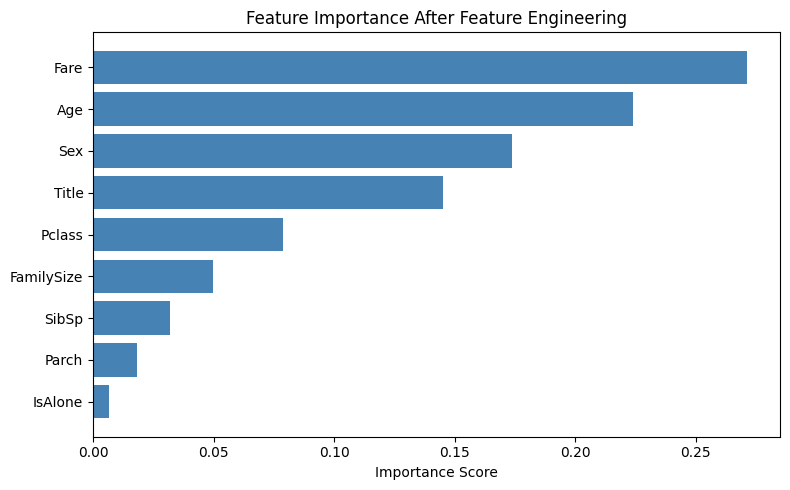

In [7]:
importance_df = pd.DataFrame({
    "Feature": X_new.columns,
    "Importance": model_new.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Feature Importance After Feature Engineering")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()